In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import itertools
import seaborn_image as isns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import scipy.stats as stats

import scienceplots
# plt.style.use('science')
sns.set(font_scale=2) 
sns.set_style("ticks")
import warnings
warnings.filterwarnings("ignore")

In [127]:
# color palette(s)
triple = ['gray', 'red','Tab:blue']

# Define functions

In [2]:
def preprocess_plot(df, name, plotting = True):
    ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
       'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)']

    for column in ls:
        df[column] = pd.to_numeric(df[column])

        if column in ['isi_(ms)', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'AHP_(mV)']:
            param_df = df[df.I_zero != 'silent']
        
        # _, p = stats.ttest_ind(df[(df['Behaviour_6hFD'] == 'Pre')][column].dropna(),
        #                             df[df['Behaviour_6hFD'] == 'Post'][column].dropna(),
        #                             equal_var = True)
        else:
            param_df = df
        
        try:
            unique_cat = df.Behaviour_6hFD.unique()
            combos = list(itertools.combinations(unique_cat, 2))

            for combo in combos:

                _, p = stats.mannwhitneyu(param_df[(param_df.Behaviour_6hFD == combo[0])][column].dropna(),
                                        param_df[(param_df.Behaviour_6hFD == combo[1])][column].dropna())
            
                print(column, combo, p)

           
        except ValueError:
            
            continue

        if plotting:
            try:
                
                fig,ax = plt.subplots(figsize = (3,3))
            
                sns.swarmplot(x='Behaviour_6hFD', y =column, data= param_df, palette = ['darkgray', '#F97306'], alpha = 1, size = 3)
                sns.boxplot(x='Behaviour_6hFD', y =column, data= param_df, palette = ['darkgray', '#F97306'], boxprops=dict(alpha=0.7), width = 0.5)
                sns.despine()
                plt.title(column, pad = 20)
                plt.xticks(rotation = 90)
                plt.savefig(f'output_figures/{name}_{column}.png',dpi = 300, bbox_inches = 'tight')
                plt.show()
            except KeyError:
                pass
                

def proportion(df, column1, column2, cols):
    prop = pd.crosstab(df[column1], df[column2], margins = True).reset_index()
    prop = prop.set_index(column1)
    print(prop)
    prop = prop.iloc[:-1, :-1]
    stat, p, dof, expected  = stats.chi2_contingency(prop)
    print(p)
    
    prop = prop.apply(lambda x: x.div(x.sum()).mul(100), axis=1)
    
    
    prop = prop[cols]
    prop = prop.reset_index()
    return prop

def prop_plot(df, column):
    df.plot(x = column, 
              kind = 'bar', 
              stacked = True,  
              mark_right = False,
              color = ['black', 'darkgray','gray'],
              figsize = (3,5), alpha = 0.7)
    plt.xticks(rotation = 0)
    ax = plt.gca()
    plt.ylabel('Percentage (%)')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

def remove_outlier(df_in, col_name):
    q1 = df_in[col_name].quantile(0.25)
    q3 = df_in[col_name].quantile(0.75)
    iqr = q3-q1 #Interquartile range
    fence_low  = q1-1.5*iqr
    fence_high = q3+1.5*iqr
    df_out = df_in.loc[(df_in[col_name] > fence_low) & (df_in[col_name] < fence_high)]
    return df_out

# Ephys analysis - panMPOA

In [3]:
ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
       'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)']

df = pd.read_csv('ephys_analysis_MC.csv')
df['experiment_day'] = df['experiment_day'].apply(lambda x: str(x).upper()[:13])
df.loc[df.Behaviour_6hFD =='No_FD','Behaviour_6hFD'] = 'Pre'
# df.loc[df.Behaviour_6hFD =='Agg+','Behaviour_6hFD'] = 'Post'
df.rename(columns = {'Instant_freq_(Hz)_1/ISI':'Instant_freq_(Hz)'}, inplace =True)

cat = df.Behaviour_6hFD.unique()

gal = df[df.Gal_positive == 'yes']
no_gal = df[df.Gal_positive == 'no']
ephys = df[df.Gal_positive.isin(['Unknown', 'no'])]
ephys = pd.concat([df[(df.Gal_positive.isin(['Unknown','no']) & (df.Behaviour_6hFD == 'Pre'))], df[df.Behaviour_6hFD.isin(cat)]])
sample_num= int(no_gal.shape[0]/4)
ephys = pd.concat([ephys, gal.sample(n = sample_num, random_state = 859)]).reset_index(drop = True)


ephys.to_csv('sampled_ephys_data.csv')

In [4]:
ephys.Behaviour_6hFD.unique()

array(['Pre', 'Agg+', 'Agg-', 'npy_antag', 'npy_10', 'npy_100',
       'agrp_100', 'ZD7288'], dtype=object)

## All properties

Cm(pF) ('Pre', 'Agg+') 0.13451684745243198
Firing_freq_(Hz)_I0 ('Pre', 'Agg+') 0.009987674731723671
Firing_freq_(Hz)_I0 ('Pre', 'Agg-') 0.16216453701428202
Firing_freq_(Hz)_I0 ('Pre', 'npy_antag') 0.08451642260745938
Firing_freq_(Hz)_I0 ('Pre', 'ZD7288') 0.0008465083366840831
Firing_freq_(Hz)_I0 ('Agg+', 'Agg-') 0.004486801649781591
Firing_freq_(Hz)_I0 ('Agg+', 'npy_antag') 0.0021884832654053485
Firing_freq_(Hz)_I0 ('Agg+', 'ZD7288') 0.07035729716684266
Firing_freq_(Hz)_I0 ('Agg-', 'npy_antag') 0.9861734114881322
Firing_freq_(Hz)_I0 ('Agg-', 'ZD7288') 0.001635310075720074
Firing_freq_(Hz)_I0 ('npy_antag', 'ZD7288') 0.0010206517764102872


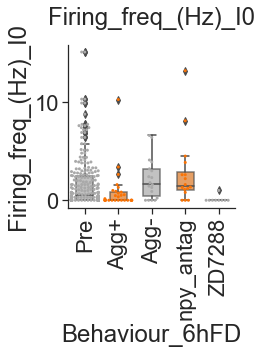

Instant_freq_(Hz) ('Pre', 'Agg+') 0.006874220766097158
Instant_freq_(Hz) ('Pre', 'Agg-') 0.3086567666222686
Instant_freq_(Hz) ('Pre', 'npy_antag') 0.11930593650386898
Instant_freq_(Hz) ('Pre', 'ZD7288') 0.0011462287096359956
Instant_freq_(Hz) ('Agg+', 'Agg-') 0.00951248466124584
Instant_freq_(Hz) ('Agg+', 'npy_antag') 0.003268762722197171
Instant_freq_(Hz) ('Agg+', 'ZD7288') 0.07984286073445584
Instant_freq_(Hz) ('Agg-', 'npy_antag') 0.6773994282128247
Instant_freq_(Hz) ('Agg-', 'ZD7288') 0.0039663584734250515
Instant_freq_(Hz) ('npy_antag', 'ZD7288') 0.0028003326500912855


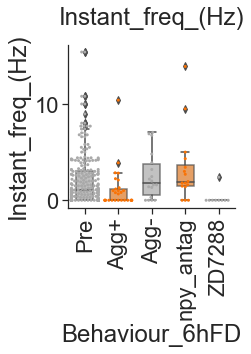

isi_(ms) ('Pre', 'Agg+') 0.6907649348388157
isi_(ms) ('Pre', 'Agg-') 0.07011296380156032
isi_(ms) ('Pre', 'npy_antag') 0.05813578480704226
isi_(ms) ('Pre', 'ZD7288') 0.8707640661262841
isi_(ms) ('Agg+', 'Agg-') 0.02907155995483803
isi_(ms) ('Agg+', 'npy_antag') 0.018596672842396383
isi_(ms) ('Agg+', 'ZD7288') 0.7999999999999999
isi_(ms) ('Agg-', 'npy_antag') 0.827142619238411
isi_(ms) ('Agg-', 'ZD7288') 0.4
isi_(ms) ('npy_antag', 'ZD7288') 0.2857142857142857


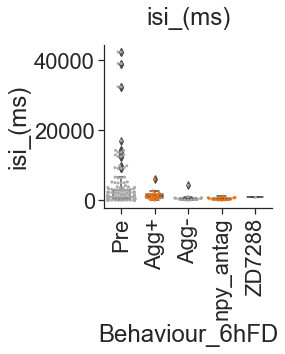

CaT ('Pre', 'Agg+') 0.1712124050690772
CaT ('Pre', 'Agg-') 0.21837149485701401
CaT ('Pre', 'npy_antag') 0.00649863938268346
CaT ('Pre', 'ZD7288') 0.5375863471949023
CaT ('Agg+', 'Agg-') 0.04037084851706265
CaT ('Agg+', 'npy_antag') 0.12548666206898038
CaT ('Agg+', 'ZD7288') 0.8170632875701833
CaT ('Agg-', 'npy_antag') 0.000834008811427322
CaT ('Agg-', 'ZD7288') 0.26973071627992273
CaT ('npy_antag', 'ZD7288') 0.08106185559577476


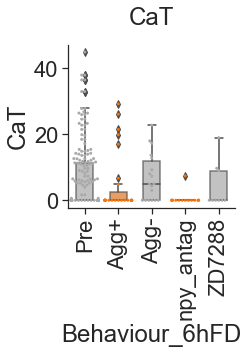

Ih_at_-120mV ('Pre', 'Agg+') 0.009430439383629686
Ih_at_-120mV ('Pre', 'Agg-') 0.42816900586681017
Ih_at_-120mV ('Pre', 'npy_antag') 0.15678189517906227
Ih_at_-120mV ('Pre', 'ZD7288') 0.0001962986617298605
Ih_at_-120mV ('Agg+', 'Agg-') 0.0011649244097342523
Ih_at_-120mV ('Agg+', 'npy_antag') 0.4289564809661256
Ih_at_-120mV ('Agg+', 'ZD7288') 0.003374911723991307
Ih_at_-120mV ('Agg-', 'npy_antag') 0.020555288302189275
Ih_at_-120mV ('Agg-', 'ZD7288') 6.0374711822455344e-05
Ih_at_-120mV ('npy_antag', 'ZD7288') 0.0006497191701663903


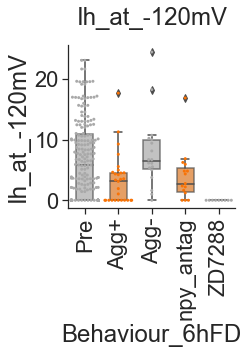

AP_ampl ('Pre', 'Agg+') 0.6356668265471896
AP_ampl ('Pre', 'Agg-') 0.5542059873726549
AP_ampl ('Pre', 'npy_antag') 0.09205388394039286
AP_ampl ('Pre', 'ZD7288') 0.7050106785218488
AP_ampl ('Agg+', 'Agg-') 0.8004638591288532
AP_ampl ('Agg+', 'npy_antag') 0.4815967507356862
AP_ampl ('Agg+', 'ZD7288') 1.0
AP_ampl ('Agg-', 'npy_antag') 0.4666114442601834
AP_ampl ('Agg-', 'ZD7288') 0.9333333333333332
AP_ampl ('npy_antag', 'ZD7288') 0.857142857142857


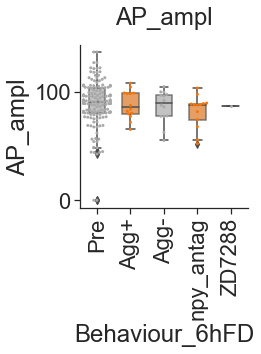

AP_halfwidth ('Pre', 'Agg+') 0.7953775043445768
AP_halfwidth ('Pre', 'Agg-') 0.03664775106270757
AP_halfwidth ('Pre', 'npy_antag') 0.054753812861011004
AP_halfwidth ('Pre', 'ZD7288') 0.6171022301477351
AP_halfwidth ('Agg+', 'Agg-') 0.11773229632209697
AP_halfwidth ('Agg+', 'npy_antag') 0.12619643972725164
AP_halfwidth ('Agg+', 'ZD7288') 0.9333333333333332
AP_halfwidth ('Agg-', 'npy_antag') 0.9806042485813652
AP_halfwidth ('Agg-', 'ZD7288') 0.7275179083713875
AP_halfwidth ('npy_antag', 'ZD7288') 1.0


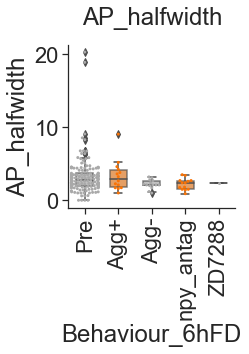

AP_time_to_peak ('Pre', 'Agg+') 0.1410590813350076
AP_time_to_peak ('Pre', 'Agg-') 0.8069454781430099
AP_time_to_peak ('Pre', 'npy_antag') 0.6768135495503365
AP_time_to_peak ('Pre', 'ZD7288') 0.428409838650341
AP_time_to_peak ('Agg+', 'Agg-') 0.20582824559459312
AP_time_to_peak ('Agg+', 'npy_antag') 0.24359324877321087
AP_time_to_peak ('Agg+', 'ZD7288') 1.0
AP_time_to_peak ('Agg-', 'npy_antag') 0.8076571133648746
AP_time_to_peak ('Agg-', 'ZD7288') 0.35151159561861045
AP_time_to_peak ('npy_antag', 'ZD7288') 0.38157390570502137


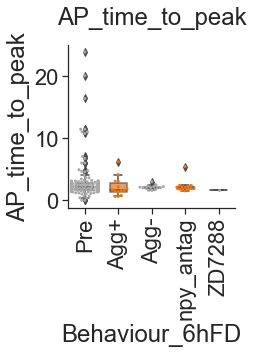

area(mV_ms) ('Pre', 'Agg+') 0.6589289916379197
area(mV_ms) ('Pre', 'Agg-') 0.0196226418680033
area(mV_ms) ('Pre', 'npy_antag') 0.026684906399262093
area(mV_ms) ('Pre', 'ZD7288') 0.4558777724589642
area(mV_ms) ('Agg+', 'Agg-') 0.3701980812474539
area(mV_ms) ('Agg+', 'npy_antag') 0.34124913800172174
area(mV_ms) ('Agg+', 'ZD7288') 1.0
area(mV_ms) ('Agg-', 'npy_antag') 0.8169613217153913
area(mV_ms) ('Agg-', 'ZD7288') 0.7999999999999999
area(mV_ms) ('npy_antag', 'ZD7288') 1.0


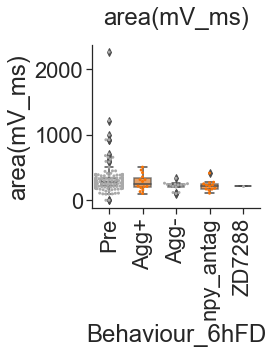

rheobase_at_-60mV_(pA) ('Pre', 'Agg+') 0.12814366123028542
rheobase_at_-60mV_(pA) ('Pre', 'Agg-') 0.09585561688012734
rheobase_at_-60mV_(pA) ('Pre', 'npy_antag') 0.11750230509400313
rheobase_at_-60mV_(pA) ('Pre', 'ZD7288') 0.02596626885505535
rheobase_at_-60mV_(pA) ('Agg+', 'Agg-') 0.8695672027305821
rheobase_at_-60mV_(pA) ('Agg+', 'npy_antag') 0.7762368827794424
rheobase_at_-60mV_(pA) ('Agg+', 'ZD7288') 0.012569560720789354
rheobase_at_-60mV_(pA) ('Agg-', 'npy_antag') 0.8284118992189651
rheobase_at_-60mV_(pA) ('Agg-', 'ZD7288') 0.015325523293282461
rheobase_at_-60mV_(pA) ('npy_antag', 'ZD7288') 0.020142478282843237


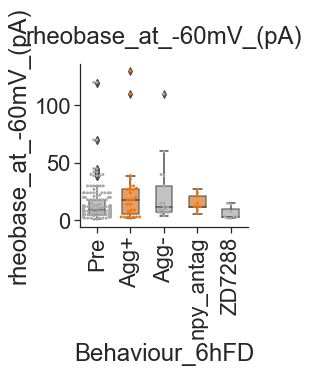

AHP_(mV) ('Pre', 'Agg+') 0.8046015121028867
AHP_(mV) ('Pre', 'Agg-') 0.7679264781570834
AHP_(mV) ('Pre', 'npy_antag') 0.30881923337598494
AHP_(mV) ('Pre', 'ZD7288') 0.8615567631879469
AHP_(mV) ('Agg+', 'Agg-') 1.0
AHP_(mV) ('Agg+', 'npy_antag') 0.7522964425151529
AHP_(mV) ('Agg+', 'ZD7288') 0.5624846616632901
AHP_(mV) ('Agg-', 'npy_antag') 0.5602953963939314
AHP_(mV) ('Agg-', 'ZD7288') 0.7999999999999999
AHP_(mV) ('npy_antag', 'ZD7288') 0.7142857142857142


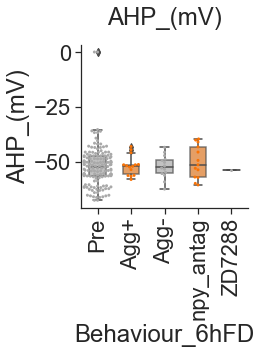

Vm ('Pre', 'Agg+') 0.567069169857365
Vm ('Pre', 'Agg-') 0.7321748622996278
Vm ('Pre', 'npy_antag') 0.07059557663472053
Vm ('Pre', 'ZD7288') 0.06292395905143515
Vm ('Agg+', 'Agg-') 0.5768086443196911
Vm ('Agg+', 'npy_antag') 0.0856036718206703
Vm ('Agg+', 'ZD7288') 0.0799305653923096
Vm ('Agg-', 'npy_antag') 0.26213613012248116
Vm ('Agg-', 'ZD7288') 0.2076174111548459
Vm ('npy_antag', 'ZD7288') 0.6711254583898127


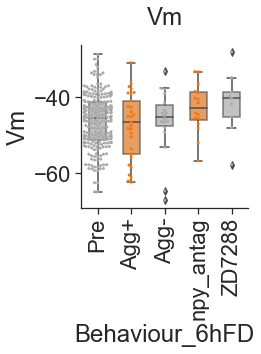

Input_Resistance ('Pre', 'Agg+') 0.005607881939624394
Input_Resistance ('Pre', 'Agg-') 0.26454678743579974
Input_Resistance ('Pre', 'npy_antag') 0.5770454664250786
Input_Resistance ('Pre', 'ZD7288') 0.0032275160977497277
Input_Resistance ('Agg+', 'Agg-') 0.00817812097305373
Input_Resistance ('Agg+', 'npy_antag') 0.17784325470182227
Input_Resistance ('Agg+', 'ZD7288') 0.1963273657820963
Input_Resistance ('Agg-', 'npy_antag') 0.2961900243021126
Input_Resistance ('Agg-', 'ZD7288') 0.001306022374090625
Input_Resistance ('npy_antag', 'ZD7288') 0.03483238234691384


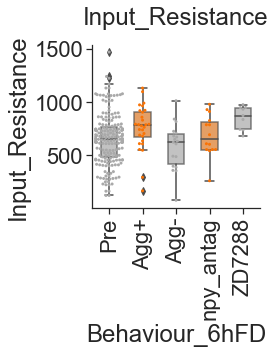

sPSC_frequency ('Pre', 'Agg+') 0.7025731164511213
sPSC_frequency ('Pre', 'Agg-') 0.9638323443580069
sPSC_frequency ('Pre', 'npy_antag') 0.3248539041649623
sPSC_Amplitude(pA) ('Pre', 'Agg+') 0.9107189625813171
sPSC_Amplitude(pA) ('Pre', 'Agg-') 0.01624452166441718
sPSC_Amplitude(pA) ('Pre', 'npy_antag') 0.11000275153659375
sPSCs_Rise time ('Pre', 'Agg+') 0.1751566179209043
sPSCs_Rise time ('Pre', 'Agg-') 0.21650937083870048
sPSCs_Rise time ('Pre', 'npy_antag') 0.0003367771844382967
sPSCs (decay) ('Pre', 'Agg+') 0.7994251156426382
sPSCs (decay) ('Pre', 'Agg-') 0.3803528575748092
sPSCs (decay) ('Pre', 'npy_antag') 0.22400627642474635


In [5]:
filter_cat = ['Pre', 'Agg+', 'Agg-', 'npy_antag', 'ZD7288']
preprocess_plot(ephys[ephys.Behaviour_6hFD.isin(filter_cat)], 'pan')


## Individual plots - panMPOA

In [128]:
ephys.head()

,experiment_day,sex,Gal_positive,state,estrous_stage,ID_mouse,Genotype,Behaviour_6hFD,Cm(pF),Adaptive,...,Vm,Input_Resistance,sPSC_frequency,sPSC_Amplitude(pA),sPSCs_Rise time,sPSCs (decay),AC-I0,AC_-60,Comments,Unnamed: 35
0,S1C1 20012023,F,no,Virgin-Gal -,P,JKAM54.2d,Gal-cre KI87; Rosa26 Tomato (Ai9),Pre,65.734306,no,...,-49.128138,250.106759,0.683099,7.7800,1.0,6.4965,NaN,NaN,NaN,NaN
1,S1C2 20012023,F,no,Virgin-Gal -,P,JKAM54.2d,Gal-cre KI87; Rosa26 Tomato (Ai9),Pre,75.822056,?,...,-50.497848,122.285453,0.826316,16.7550,1.1,8.8464,NaN,NaN,NaN,NaN
2,S1C3 20012023,F,no,Virgin-Gal -,P,JKAM54.2d,Gal-cre KI87; Rosa26 Tomato (Ai9),Pre,50.911152,yes,...,-53.084624,672.766784,3.153537,9.6000,1.1,8.3191,NaN,NaN,NaN,NaN
3,S2C4 20012023,F,no,Virgin-Gal -,P,JKAM54.2d,Gal-cre KI87; Rosa26 Tomato (Ai9),Pre,21.407586,no,...,-42.987736,744.864094,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,S2C5 20012023,F,no,Virgin-Gal -,P,JKAM54.2d,Gal-cre KI87; Rosa26 Tomato (Ai9),Pre,40.243429,yes,...,-55.055603,627.416182,4.314286,8.3206,1.0,9.4346,NaN,NaN,NaN,NaN


In [129]:
# list(ephys.columns)

In [111]:
# subset df for those groups needed for firing freq. plot
ephys2 = ephys.loc[(ephys['Behaviour_6hFD'] == 'Pre') | (ephys['Behaviour_6hFD'] == 'Agg+') |(ephys['Behaviour_6hFD'] == 'Agg-')]

339

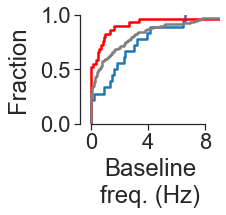

In [146]:
# Firing frequency

sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2) 
sns.set_style("ticks")

cum = sns.ecdfplot(data=ephys2, x="Firing_freq_(Hz)_I0", hue="Behaviour_6hFD", palette = triple, linewidth=2.5, legend=False, stat='proportion')
cum.set_xlabel('Baseline\nfreq. (Hz)',labelpad=5)
cum.set_ylabel('Fraction',labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_5/linked_figure5/ff.pdf',dpi=300,bbox_inches='tight')

In [150]:
# len(ephys[ephys[('Behaviour_6hFD') == 'Pre']].Vm)

len(ephys[(ephys['Behaviour_6hFD'] == 'Pre')].Vm)

# df[(df['projection_site'] == 'pan') & (df['state'] == 'D10')]

246

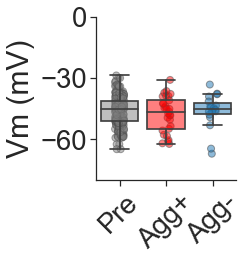

In [131]:
# Membrane voltage / RMP

sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Vm', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='Vm', data = ephys, order = ['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = triple, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=5)

ax.set_xticklabels( ('Pre', 'Agg+', 'Agg-'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_5/linked_figure5/Vm.pdf',dpi=300,bbox_inches='tight')

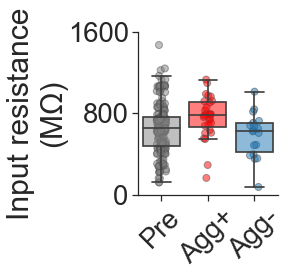

In [133]:
# Input resistance

sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys, order = ['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = triple, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Input resistance\n(MΩ)', labelpad=0)

ax.set_xticklabels( ('Pre', 'Agg+', 'Agg-'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(2))
plt.ylim(0, 1600)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_5/linked_figure5/Ri.pdf',dpi=300,bbox_inches='tight')

OverflowError: Range exceeds valid bounds

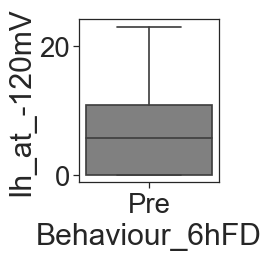

In [199]:
# Ih
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys, order = ['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = triple, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('$\mathregular{I_{h}}$ current (pA)', labelpad=0)

ax.set_xticklabels( ('Pre', 'Agg+', 'Agg-'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-2, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_5/linked_figure5/Ih.pdf',dpi=300,bbox_inches='tight')

Cm(pF) ('Pre', 'Agg+') 0.568000349055369


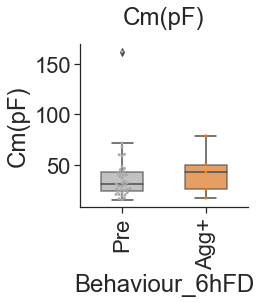

Firing_freq_(Hz)_I0 ('Pre', 'Agg+') 0.28721546260366726


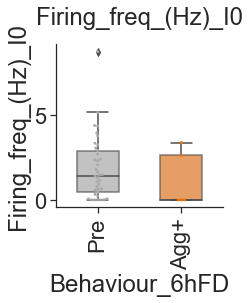

Instant_freq_(Hz) ('Pre', 'Agg+') 0.2541927698038654


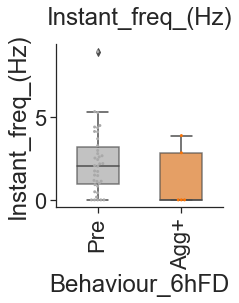

isi_(ms) ('Pre', 'Agg+') 0.3025210084033614


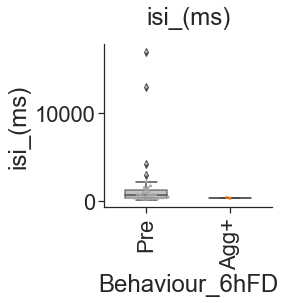

CaT ('Pre', 'Agg+') 0.09172696328617409


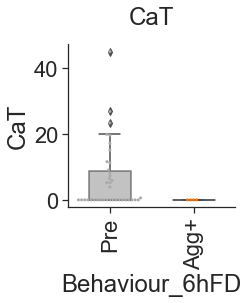

Ih_at_-120mV ('Pre', 'Agg+') 0.34655777807143007


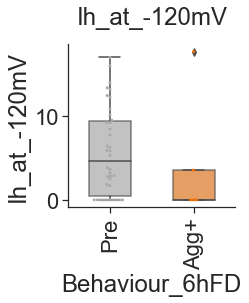

AP_ampl ('Pre', 'Agg+') 0.27062944050876925


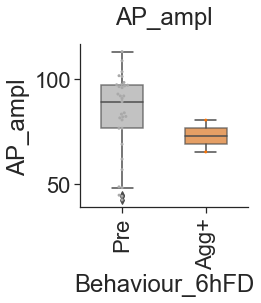

AP_halfwidth ('Pre', 'Agg+') 0.7563025210084033


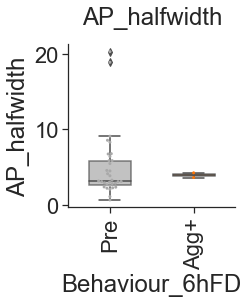

AP_time_to_peak ('Pre', 'Agg+') 0.1411764705882353


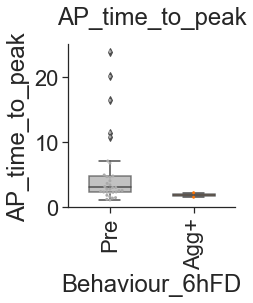

area(mV_ms) ('Pre', 'Agg+') 0.3697478991596639


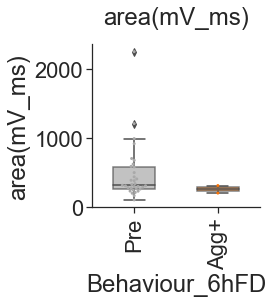

rheobase_at_-60mV_(pA) ('Pre', 'Agg+') 0.12860985215882415


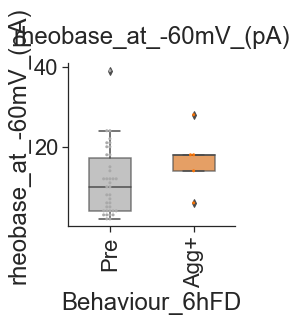

AHP_(mV) ('Pre', 'Agg+') 0.27226890756302524


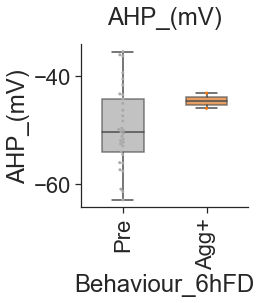

Vm ('Pre', 'Agg+') 0.568000349055369


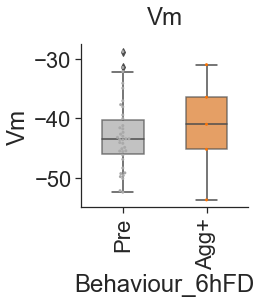

Input_Resistance ('Pre', 'Agg+') 0.9560979765177156


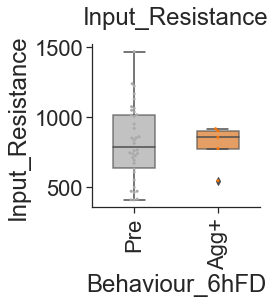

sPSC_frequency ('Pre', 'Agg+') 0.07868653086044392


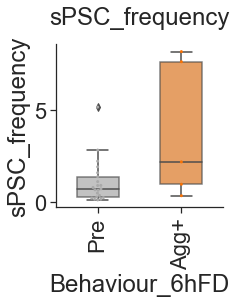

sPSC_Amplitude(pA) ('Pre', 'Agg+') 0.8010337488598358


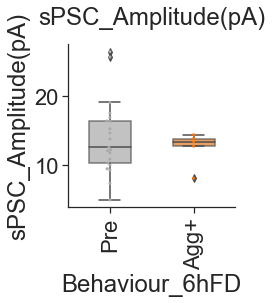

In [6]:
preprocess_plot(gal,'gal')

Cm(pF) ('Pre', 'Agg+') 0.4312064746847355


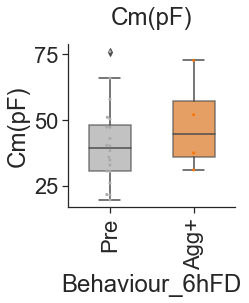

Firing_freq_(Hz)_I0 ('Pre', 'Agg+') 0.4034858988262905


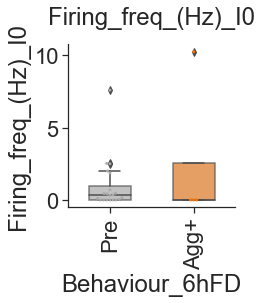

Instant_freq_(Hz) ('Pre', 'Agg+') 0.4034858988262905


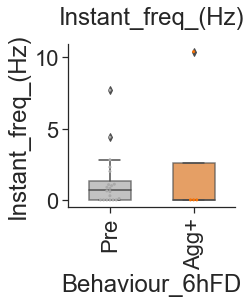

isi_(ms) ('Pre', 'Agg+') 0.13333333333333333


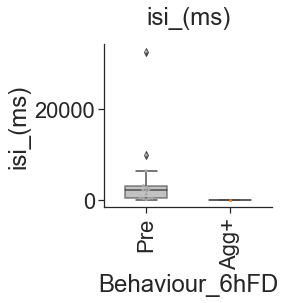

CaT ('Pre', 'Agg+') 0.18249580310381686


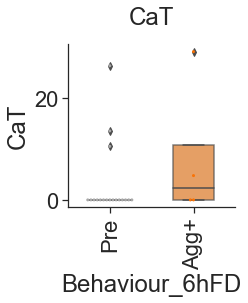

Ih_at_-120mV ('Pre', 'Agg+') 0.9339723158912411


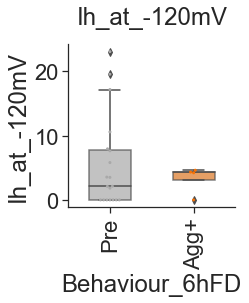

AP_ampl ('Pre', 'Agg+') 0.5333333333333333


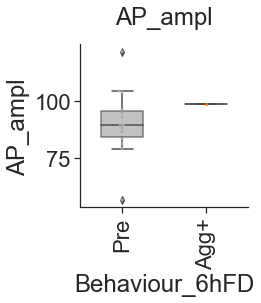

AP_halfwidth ('Pre', 'Agg+') 0.2971897434333751


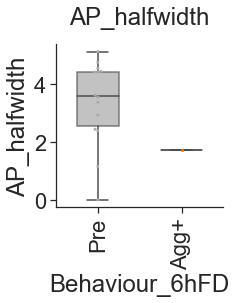

AP_time_to_peak ('Pre', 'Agg+') 0.26666666666666666


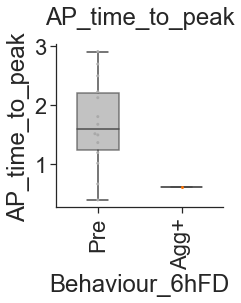

area(mV_ms) ('Pre', 'Agg+') 0.4


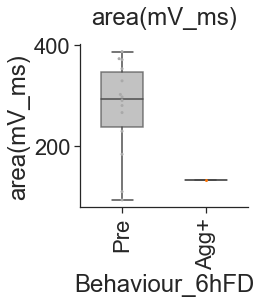

rheobase_at_-60mV_(pA) ('Pre', 'Agg+') 0.5152684554887583


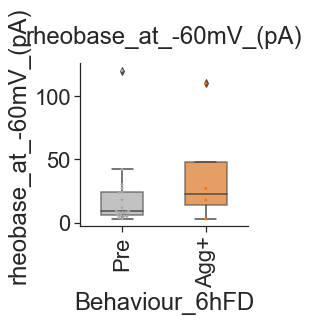

AHP_(mV) ('Pre', 'Agg+') 1.0


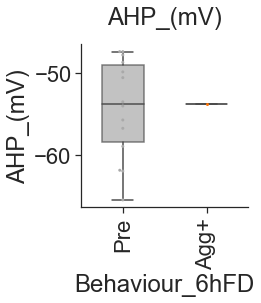

Vm ('Pre', 'Agg+') 0.08112177677395067


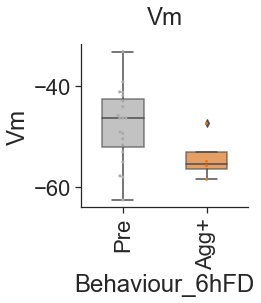

Input_Resistance ('Pre', 'Agg+') 0.9068322981366461


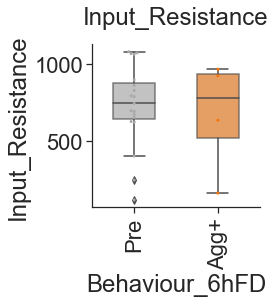

sPSC_frequency ('Pre', 'Agg+') 0.9700734048560136


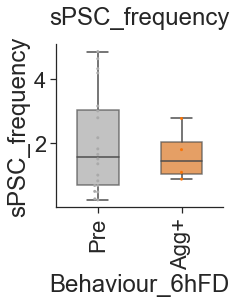

sPSC_Amplitude(pA) ('Pre', 'Agg+') 0.8161651409276747


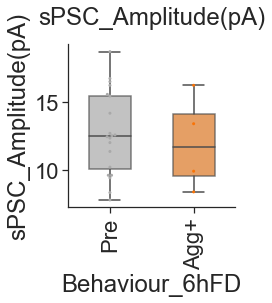

sPSCs_Rise time ('Pre', 'Agg+') 0.7224445223795837


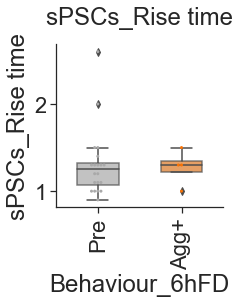

sPSCs (decay) ('Pre', 'Agg+') 1.0


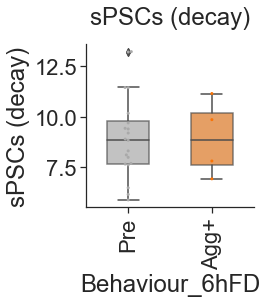

In [7]:
preprocess_plot(no_gal,'gal_minus')

Cm(pF) 0.7323693239926063


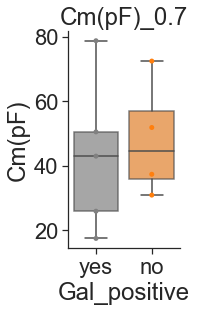

Firing_freq_(Hz)_I0 0.6407646405225094


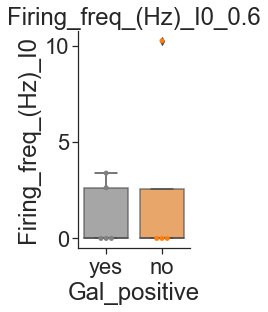

Instant_freq_(Hz) 0.6729139443059836


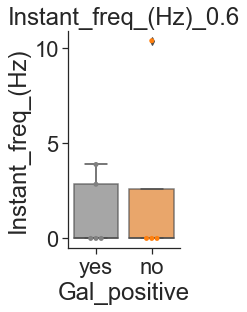

isi_(ms) 0.264690461240659


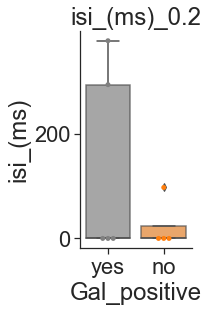

CaT 0.31129113670632236


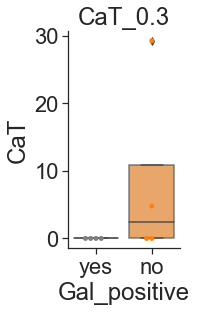

Ih_at_-120mV 0.8027274535869496


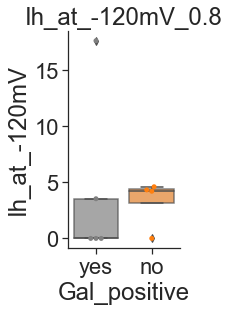

AP_ampl 0.8859255231987084


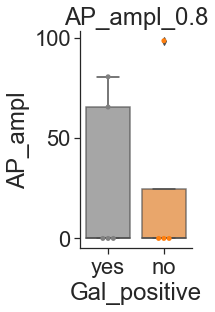

AP_halfwidth 0.32548590700011526


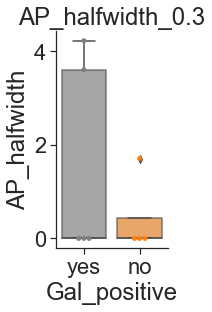

AP_time_to_peak 0.2899382771639767


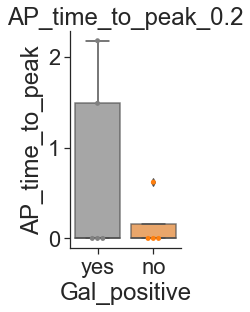

area(mV_ms) 0.37498685458791303


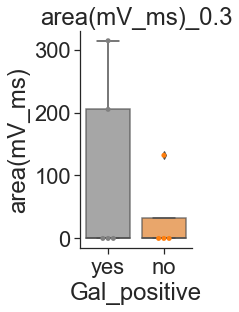

rheobase_at_-60mV_(pA) 0.4161053280322605


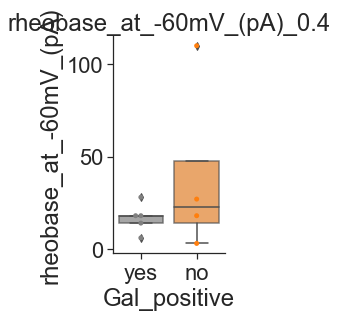

AHP_(mV) 0.80731274924489


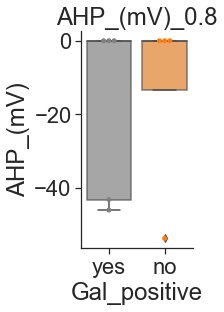

Vm 0.029015379302906888


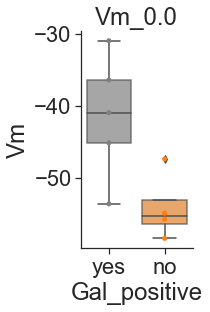

Input_Resistance 0.5478892229399508


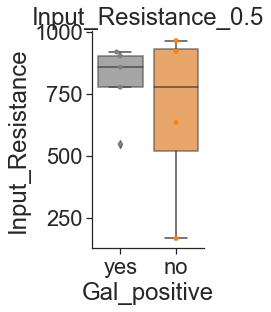

sPSC_frequency 0.2622481192712615


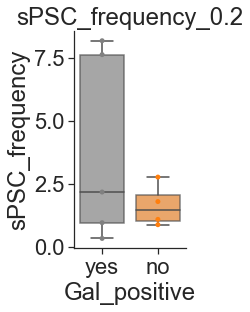

sPSC_Amplitude(pA) 0.8336416545013177


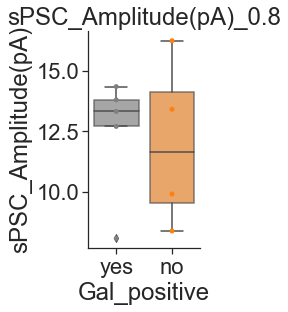

sPSCs_Rise time 0.15061956182763336


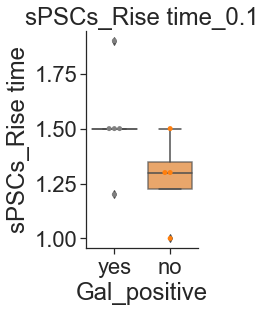

sPSCs (decay) 0.1946103198988765


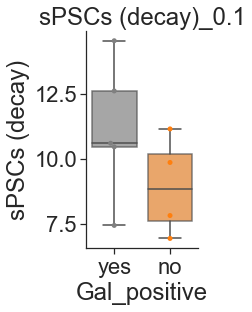

AC-I0 nan
AC_-60 nan


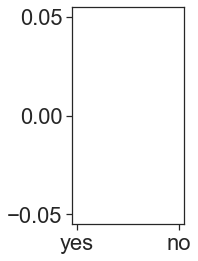

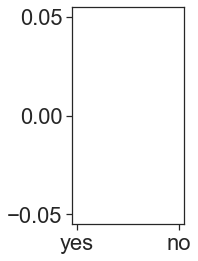

In [8]:
gals = pd.concat([gal,no_gal], axis = 0)
gals = gals[gals.Behaviour_6hFD.isin(['Agg+', 'Agg-'])]

ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
   'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)', 'AC-I0', 'AC_-60']

for column in ls:
    try:
        _, p = stats.ttest_ind(gals[(gals.Gal_positive == 'yes')][column].dropna(),
                                    gals[(gals.Gal_positive == 'no')][column].dropna(),
                                    equal_var = False)
        print(column , p)


        gals[column] = pd.to_numeric(gals[column])
        fig,ax = plt.subplots(figsize = (2,4))
        sns.swarmplot(x='Gal_positive', y =column, data= gals, palette = ['gray', 'Tab:orange'])
        sns.boxplot(x='Gal_positive', y =column, data= gals, palette = ['gray', 'Tab:orange'], boxprops=dict(alpha=0.7))
        sns.despine()
        plt.title(column + '_' + str(p)[:3])
        plt.savefig(f'output_figures/gal_nogal_{column}.png',dpi = 300, bbox_inches = 'tight')
        plt.show()
    except Exception:
        continue

In [9]:
trial = ephys[ephys.Behaviour_6hFD.isin(['Pre', 'Agg-', 'Agg+'])]
trial = trial.rename(columns={'Ih_at_-120mV': 'ih_current', 'Firing_freq_(Hz)_I0': 'firing_freq'})
model = smf.ols('ih_current ~  I_zero_reclassified  ', data=trial).fit()
#model.summary()
sm.stats.anova_lm(model, typ=2)

,sum_sq,df,F,PR(>F)
I_zero_reclassified,75.862343,2.0,0.993219,0.371906
Residual,9127.445165,239.0,NaN,NaN


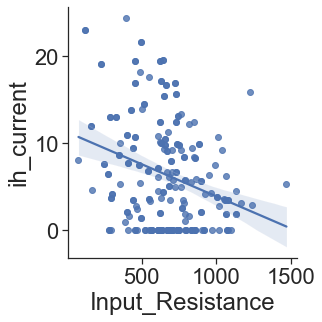

In [10]:
sns.lmplot(x = 'Input_Resistance', y = 'ih_current', data = trial, palette = ['darkgray', '#F97306', 'blue'])
          


No handles with labels found to put in legend.


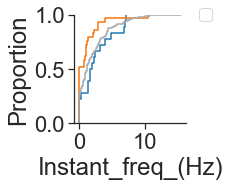

In [11]:
l = 'Instant_freq_(Hz)'
max = ephys[l].max()
cs = ['darkgray', '#F97306', 'Tab:blue']
conds = ['Pre', 'Agg+', 'Agg-']

fig, ax = plt.subplots(figsize=(2, 2))
sns.ecdfplot(data=ephys[ephys.Behaviour_6hFD.isin(conds)], x=l, hue="Behaviour_6hFD", palette = cs, ax = ax)
sns.despine()
plt.legend(loc='center left', bbox_to_anchor=(1.05, 1), fontsize = 16)

plt.savefig(f'output_figures/ECDF_{l}.png',dpi = 300, bbox_inches = 'tight')
plt.show()

    

## Proportion of silent neurons

I_zero          phasic  silent  tonic  All
Behaviour_6hFD                            
Agg+                 6      15      8   29
Agg-                 2       4     12   18
Pre                 40      60    142  242
agrp_100             0       4      4    8
npy_10               0       5      1    6
npy_100              0       1      0    1
npy_antag            4       3      9   16
All                 52      92    176  320
0.006018435514743386


Text(0.5, 1.0, 'silent_prop')

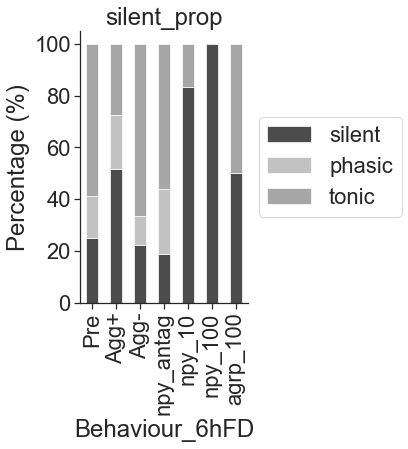

In [12]:
## silent proportion
cols = ['silent', 'phasic', 'tonic']
cat = ['Pre', 'Agg+', 'Agg-', 'npy_antag', 'npy_10','npy_100', 'agrp_100']
silent_prop = proportion(ephys[ephys.Behaviour_6hFD.isin(cat)], 'Behaviour_6hFD', 'I_zero', cols)
silent_prop['Behaviour_6hFD'] = pd.Categorical(silent_prop['Behaviour_6hFD'], cat)
silent_prop = silent_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(silent_prop, 'Behaviour_6hFD')
plt.xticks(rotation = 90)
plt.title('silent_prop')

In [19]:
silent_prop

I_zero,Behaviour_6hFD,silent,phasic,tonic,silent_frac
2,Pre,24.793388,16.528926,58.677686,0.247934
0,Agg+,51.724138,20.689655,27.586207,0.517241
1,Agg-,22.222222,11.111111,66.666667,0.222222
6,npy_antag,18.750000,25.000000,56.250000,0.187500
4,npy_10,83.333333,0.000000,16.666667,0.833333
5,npy_100,100.000000,0.000000,0.000000,1.000000
3,agrp_100,50.000000,0.000000,50.000000,0.500000


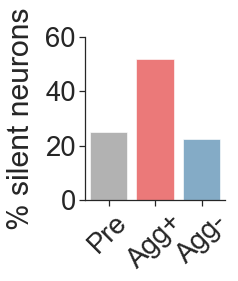

In [136]:
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(silent_prop, x="Behaviour_6hFD", y="silent", order=['Pre', 'Agg+', 'Agg-'], palette = triple, alpha=0.6)
g.yaxis.set_major_locator(plt.MaxNLocator(3)) 
plt.ylabel('% silent neurons', labelpad=10)
g.set_xticklabels(('Pre', 'Agg+', 'Agg-'), rotation=45)
plt.xlabel('')
plt.ylim(0,60)
sns.despine(bottom=False)
# g.tick_params(bottom=False)
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_5/linked_figure5/silent_prop.pdf',dpi=300,bbox_inches='tight')

## Gal-specific silent proportion

In [ ]:
cols = ['silent', 'tonic']
silent_prop = proportion(gals, 'Gal_positive', 'I_zero', cols)
silent_prop['Gal_positive'] = pd.Categorical(silent_prop['Gal_positive'], ['yes', 'no'])
silent_prop = silent_prop.sort_values(by = ['Gal_positive'])
prop_plot(silent_prop, 'Gal_positive')
plt.title('galanin_silent_prop')
plt.savefig('output_figures/galanin_silent_prop.png',dpi = 300, bbox_inches = 'tight')

## adaptive prop

In [ ]:
## adaptive proportion
cols = ['yes', 'no']
cat = ['Pre', 'Agg+', 'Agg-', 'npy_antag', 'npy_10', 'agrp_100', 'ZD7288']
ad_prop = proportion(ephys[ephys.Behaviour_6hFD.isin(cat)], 'Behaviour_6hFD', 'Adaptive', cols)
ad_prop['Behaviour_6hFD'] = pd.Categorical(ad_prop['Behaviour_6hFD'], cat)
ad_prop = ad_prop.sort_values(by = ['Behaviour_6hFD'])

prop_plot(ad_prop, 'Behaviour_6hFD')
plt.xticks(rotation = 90)
plt.title('adaptive_prop')
plt.savefig('output_figures/adaptive_prop.png',dpi = 300, bbox_inches = 'tight')

In [ ]:
cols = ['yes', 'no']
ad_prop = proportion(gals, 'Gal_positive', 'Adaptive', cols)
ad_prop['Gal_positive'] = pd.Categorical(ad_prop['Gal_positive'], ['yes', 'no'])
ad_prop = ad_prop.sort_values(by = ['Gal_positive'])
prop_plot(ad_prop, 'Gal_positive')
plt.title('galanin_adaptive_prop')
plt.savefig('output_figures/galanin_adaptive_prop.png',dpi = 300, bbox_inches = 'tight')

## calcium T prop

In [ ]:
## calcium T proportion
cols = ['no', 'yes']
ca_prop = proportion(ephys, 'Behaviour_6hFD', 'cat_categ', cols)
ca_prop['Behaviour_6hFD'] = pd.Categorical(ca_prop['Behaviour_6hFD'],cat)
ca_prop = ca_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(ca_prop, 'Behaviour_6hFD')
plt.xticks(rotation = 90)

plt.title('CaT_prop')
plt.savefig('output_figures/CaT_prop.png',dpi = 300, bbox_inches = 'tight')

In [ ]:
cols = ['yes', 'no']
ca_prop = proportion(gals, 'Gal_positive', 'cat_categ', cols)
ca_prop['Gal_positive'] = pd.Categorical(ca_prop['Gal_positive'], ['yes', 'no'])
ca_prop = ca_prop.sort_values(by = ['Gal_positive'])
prop_plot(ca_prop, 'Gal_positive')

plt.title('galanin_CaT_prop')
plt.savefig('output_figures/galanin_CaT_prop.png',dpi = 300, bbox_inches = 'tight')

In [ ]:
## prop of silent cells with/ without DB
DB_df = ephys[ephys.I_zero == 'silent']

DB_df.loc[(DB_df['Ih_at_-120mV'] == 0), 'IH']  = 'no'
DB_df.loc[(DB_df['Ih_at_-120mV'] >0 ), 'IH']  = 'yes'
DB_prop = pd.crosstab(DB_df['Behaviour_6hFD'], DB_df['IH'], margins = True).reset_index()
cols = ['Behaviour_6hFD', 'no', 'yes','All']
DB_prop = DB_prop[cols]
DB_prop['Behaviour_6hFD'] = pd.Categorical(DB_prop['Behaviour_6hFD'], cat)
DB_prop = DB_prop.sort_values(by = ['Behaviour_6hFD']).dropna()

plot_df = DB_prop.copy()

## chi square test
DB_prop.index = DB_prop.Behaviour_6hFD
DB_prop.drop(columns = ['Behaviour_6hFD'], inplace = True)
c, p, dof, expected = stats.chi2_contingency(DB_prop.iloc[:,:-1]) 
print(DB_prop)
print(p)

## plotting
plot_df.iloc[:, 1:5] = plot_df.iloc[:, 1:5].div(plot_df.All, axis = 0) *100
plot_df = plot_df.iloc[:, :-1]
plot_df.plot(
          x = 'Behaviour_6hFD', 
          kind = 'bar', 
          stacked = True,  
          mark_right = False,
          color = ['black','lightgray'],
          figsize = (5,7), alpha = 0.7)

ax = plt.gca()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
# plt.ylabel('percentage of neurons with Calium T')

## IH prop

In [ ]:
ephys.loc[(ephys['Ih_at_-120mV'] == 0), 'IH']  = 'no'
ephys.loc[(ephys['Ih_at_-120mV'] >0 ), 'IH']  = 'yes'
cols = ['no', 'yes']

ca_prop = proportion(ephys, 'Behaviour_6hFD', 'IH', cols)
ca_prop['Behaviour_6hFD'] = pd.Categorical(ca_prop['Behaviour_6hFD'], cat)
ca_prop = ca_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(ca_prop, 'Behaviour_6hFD')

plt.title('IH prop')
plt.xticks(rotation = 90)
plt.savefig('output_figures/IH_prop.png',dpi = 300, bbox_inches = 'tight')

In [ ]:
cols = ['yes', 'no']
ih_prop =  proportion(ephys, 'I_zero_reclassified', 'IH', cols)
# ca_prop = ca_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(ih_prop, 'I_zero_reclassified')
plt.xticks(rotation = 90)
plt.xlabel('')

# ramp analysis

In [ ]:
df = pd.read_csv('ramps_all.csv')
ephys = pd.read_csv('sampled_ephys_data.csv')
ephys.rename(columns = {'Instant_freq_(Hz)_1/ISI':'Instant_freq_(Hz)', 
                        'experiment_day':'filename'}, inplace =True)

df.rename(columns = {'I_Injected(pA)': 'Injected'}, inplace = True)
df = pd.merge(df, ephys, on = 'filename')

df['Injected'] = pd.Categorical(df['Injected'], df['Injected'].unique()[:-2]).as_ordered()

start = df['Ramp_start'][0]
num_spike = df.groupby(by = ['filename', 'Injected']).size().reset_index(name ='num_spike')
df = df.groupby(['filename', 'Injected'], dropna = False).first().reset_index().drop_duplicates()

df.loc[df['Event start '] == 0,'Event start '] = 2080
df['latency'] = df['Event start ']- start
df['num_spike'] = num_spike.num_spike
df =  pd.merge(df, ephys, on = ['filename', 'Behaviour_6hFD'])



In [ ]:
prop = 'latency'

fig = plt.subplots(figsize = [20,4])

palette = ['Tab:orange', 'gray']
ax = sns.violinplot(x ='Injected', y = prop, hue = 'Behaviour_6hFD', 
                    dodge = True, data = df,
                    palette=palette,width = 0.7,
                    scale="width", inner=None)

# ax = sns.lmplot(x ='Injected', y = prop, hue = 'Behaviour_6hFD', data = df)
xlim = ax.get_xlim()
ylim = ax.get_ylim()
for violin in ax.collections:
    bbox = violin.get_paths()[0].get_extents()
    x0, y0, width, height = bbox.bounds
    violin.set_clip_path(plt.Rectangle((x0, y0), width / 2, height, transform=ax.transData))

old_len_collections = len(ax.collections)
sns.stripplot(x  = 'Injected', y = prop, hue = 'Behaviour_6hFD',
               dodge = True, data = df, palette=palette, ax=ax)

sns.boxplot(x  = 'Injected', y = prop, hue = 'Behaviour_6hFD',
                data = df, saturation=1, showfliers=False,
            width=0.7, boxprops={'zorder': 3, 'facecolor': 'none'}, ax=ax)


for dots in ax.collections[old_len_collections:]:
    dots.set_offsets(dots.get_offsets() + np.array([.08, 0]))
    
ax.set_xlim(xlim)
ax.set_ylim(ylim)

sns.despine()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

In [ ]:
model = smf.ols('latency ~ C(Injected) * C(Behaviour_6hFD)', data=df).fit()
#model.summary()
sm.stats.anova_lm(model, typ=2)

In [ ]:
# df['combination'] = df.Injected.astype(str) + " / " + df.Behaviour_6hFD
# m_comp = pairwise_tukeyhsd(endog=df['latency'], groups=df['combination'], alpha=0.05)
# m_comp._results_table

# estrous cycle influence

I_zero         phasic  silent  tonic  All
estrous_stage                            
?                   2       2      4    8
D                  19      18     60   97
E                   7      14     22   43
M                   6       8     17   31
P                   2      10     19   31
no VS               2       4     18   24
not taken           2       4      2    8
All                40      60    142  242
0.32195013681923096
I_zero          phasic  silent  tonic  All
estrous_stage                             
D                    2       5      3   10
E                    3       1      0    4
M                    0       6      3    9
P                    1       3      2    6
to be stained        2       4     12   18
All                  8      19     20   47
0.019141675228478677


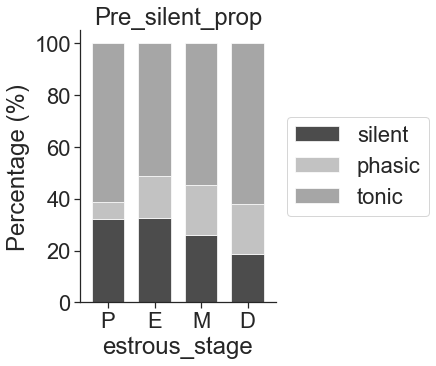

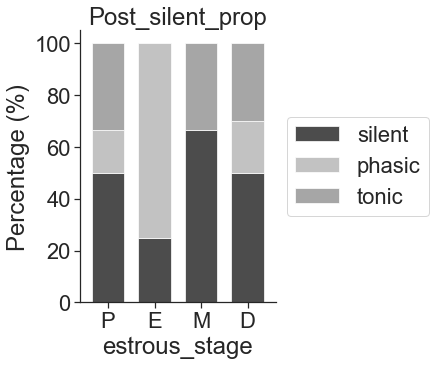

In [151]:
# silent proportion
ephys = pd.read_csv('sampled_ephys_data.csv')

ephys = ephys[ephys.I_zero.isin(['silent', 'phasic', 'tonic'])]
ephys.loc[(ephys['estrous_stage'] == 'P to E'), 'estrous_stage']  = 'P'
ephys.loc[(ephys['estrous_stage'] == 'D to P'), 'estrous_stage']  = 'D'
cols = ['silent', 'phasic', 'tonic']
ephys.loc[ephys.Behaviour_6hFD.isin(['Agg+', 'Agg-']),'Behaviour_6hFD'] = 'Post'

for state in ['Pre', 'Post']:
    state_df = ephys[ephys.Behaviour_6hFD == state]
    silent_prop = proportion(state_df, 'estrous_stage', 'I_zero', cols)
    silent_prop['estrous_stage'] = pd.Categorical(silent_prop['estrous_stage'], ['P', 'E', 'M', 'D'])
    silent_prop = silent_prop.sort_values(by = ['estrous_stage'])
    silent_prop = silent_prop[silent_prop.estrous_stage.isin(['P', 'E', 'M', 'D'])]
    


    silent_prop.plot(x = 'estrous_stage', 
            kind = 'bar', 
            stacked = True,  
            mark_right = False,
            color = ['black', 'darkgray','gray'],
            figsize = (3.5,5), alpha = 0.7, width = 0.7)
 
        
    plt.xticks(rotation = 0)
    ax = plt.gca()
    plt.ylabel('Percentage (%)')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    plt.title(f'{state}_silent_prop')
    plt.savefig(f'output_figures/{state}_silent_prop.png',dpi = 300, bbox_inches = 'tight')

I_zero          phasic  silent  tonic  All
estrous_stage                             
D                    2       5      3   10
E                    3       1      0    4
M                    0       6      3    9
P                    1       3      2    6
to be stained        2       4     12   18
All                  8      19     20   47
0.019141675228478677


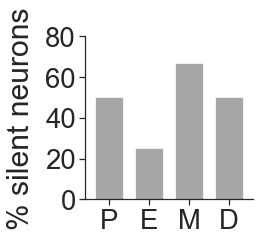

In [197]:
# silent proportion
ephys = pd.read_csv('sampled_ephys_data.csv')

ephys = ephys[ephys.I_zero.isin(['silent', 'phasic', 'tonic'])]
ephys.loc[(ephys['estrous_stage'] == 'P to E'), 'estrous_stage']  = 'P'
ephys.loc[(ephys['estrous_stage'] == 'D to P'), 'estrous_stage']  = 'D'
cols = ['silent', 'phasic', 'tonic']
ephys.loc[ephys.Behaviour_6hFD.isin(['Agg-','Agg+']),'Behaviour_6hFD'] = 'Post'

for state in ['Post']: #Post
    state_df = ephys[ephys.Behaviour_6hFD == state]
    silent_prop = proportion(state_df, 'estrous_stage', 'I_zero', cols)
    silent_prop['estrous_stage'] = pd.Categorical(silent_prop['estrous_stage'], ['P', 'E', 'M', 'D'])
    silent_prop = silent_prop.sort_values(by = ['estrous_stage'])
    silent_prop = silent_prop[silent_prop.estrous_stage.isin(['P', 'E', 'M', 'D'])]
    


    silent_prop.plot(x = 'estrous_stage', y = 'silent',
            kind = 'bar', 
            stacked = False,  
            mark_right = False,
            color = ['gray'],
            figsize = (3,3), alpha = 0.7, width = 0.7)
 
        
    
    plt.xticks(rotation = 0)
    ax = plt.gca()
    plt.ylabel('% silent neurons', labelpad=10)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    plt.xlabel(None)
    plt.ylim(0,80) 
    ax.get_legend().remove()
    ax.yaxis.set_major_locator(plt.MaxNLocator(4))

#     plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_5/linked_figure5/Pre_silent_prop.pdf',
#     dpi=300,bbox_inches='tight', transparent=True)

In [198]:
silent_prop

I_zero,estrous_stage,silent,phasic,tonic
3,P,50.000000,16.666667,33.333333
1,E,25.000000,75.000000,0.000000
2,M,66.666667,0.000000,33.333333
0,D,50.000000,20.000000,30.000000


In [ ]:
# sns.set(rc={"figure.figsize": (2.5, 3)})
# sns.set(font_scale=2.5) 
# sns.set_style("ticks")

# g = sns.barplot(silent_prop, x="Behaviour_6hFD", y="silent", order=['Pre', 'Agg+', 'Agg-'], palette = triple, alpha=0.6)
# g.yaxis.set_major_locator(plt.MaxNLocator(3)) 
# plt.ylabel('% silent neurons', labelpad=10)
# g.set_xticklabels(('Pre', 'Agg+', 'Agg-'), rotation=45)
# plt.xlabel('')
# plt.ylim(0,60)
# sns.despine(bottom=False)
# # g.tick_params(bottom=False)
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_5/linked_figure5/silent_prop.pdf',dpi=300,bbox_inches='tight')

0.9561210031081588 0.04387899689184116


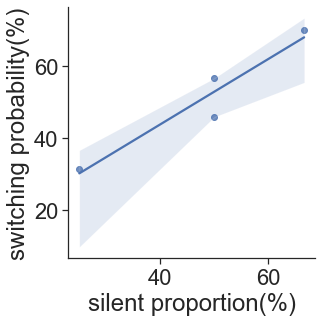

In [152]:
import scipy as sp
estrous_df = pd.read_csv('../NPS_behaviour_analysis/generated_datasets/estrous_data.csv')
estrous_df.rename(columns = {'Unnamed: 0':'estrous_stage', '0':'switching probability'}, inplace = True)
corr = pd.merge(silent_prop, estrous_df, on = 'estrous_stage')

r, p = sp.stats.pearsonr(corr['switching probability'], corr['silent'])
print(r, p)
sns.lmplot(x = 'silent', y = 'switching probability', data = corr)
plt.xlabel('silent proportion(%)')
plt.ylabel('switching probability(%)')
plt.savefig('output_figures/silent_switching_corr.png', dpi = 300, bbox_inches = 'tight')

F_onewayResult(statistic=0.4328137741108785, pvalue=0.7300797086921997)


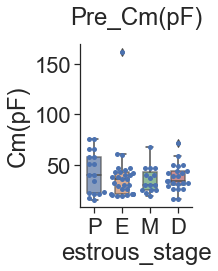

F_onewayResult(statistic=0.16419143036570535, pvalue=0.9203823289842754)


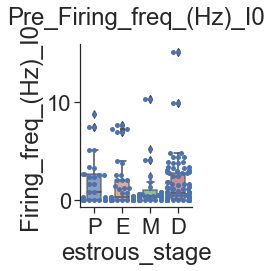

F_onewayResult(statistic=0.12925740334979846, pvalue=0.9426345590150569)


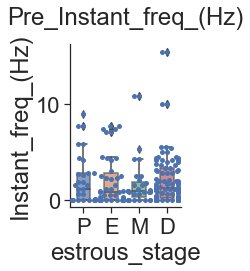

F_onewayResult(statistic=1.2774817893531523, pvalue=0.28329296020841255)


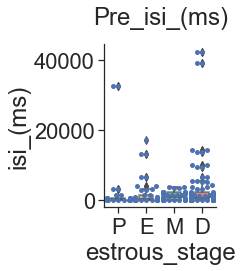

F_onewayResult(statistic=1.0513672946650927, pvalue=0.37130456278854557)


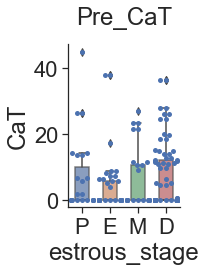

F_onewayResult(statistic=3.496561798954224, pvalue=0.016803282722984963)


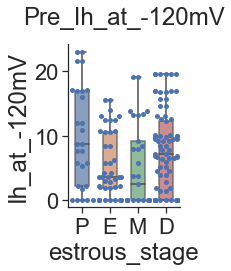

F_onewayResult(statistic=1.108879907974668, pvalue=0.3468291704323018)


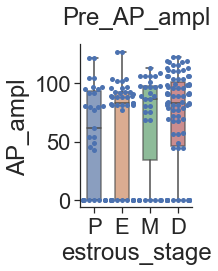

F_onewayResult(statistic=0.48869065638809406, pvalue=0.6905576403797412)


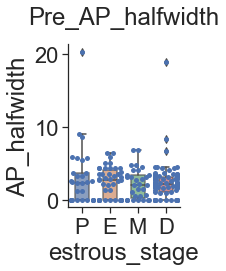

F_onewayResult(statistic=1.41581563601425, pvalue=0.23960995398410603)


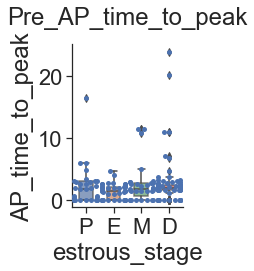

F_onewayResult(statistic=0.4114251423992339, pvalue=0.7449843408624836)


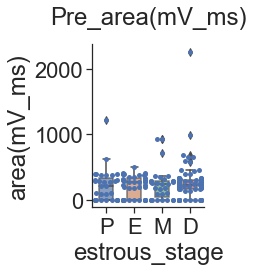

F_onewayResult(statistic=6.036369330877578, pvalue=0.00067723895268822)


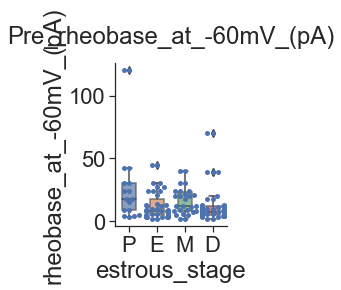

F_onewayResult(statistic=0.9158237373345464, pvalue=0.43441218449138197)


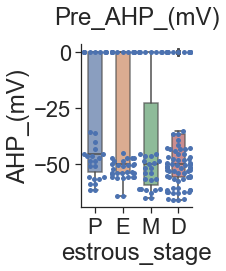

F_onewayResult(statistic=1.058407276515252, pvalue=0.36793188978376445)


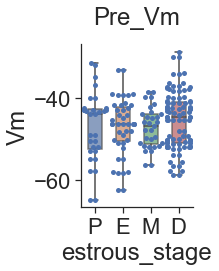

F_onewayResult(statistic=7.6427779774152125, pvalue=7.849442098541367e-05)


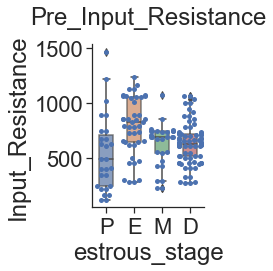

F_onewayResult(statistic=2.2883107395509414, pvalue=0.08458499824743701)


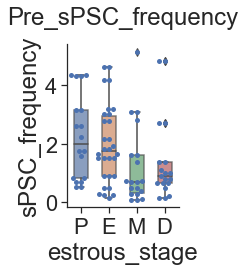

F_onewayResult(statistic=2.038060556374969, pvalue=0.11493941904586487)


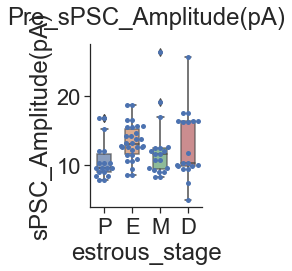

F_onewayResult(statistic=7.777574835109081, pvalue=0.0001984375516442889)


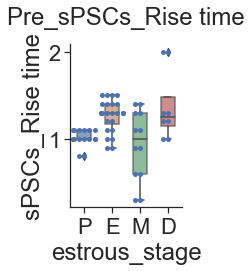

F_onewayResult(statistic=0.9926632582121734, pvalue=0.4032880968798811)


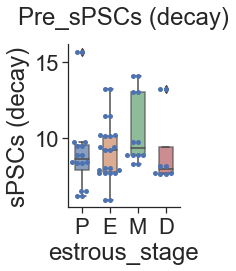

F_onewayResult(statistic=1.1688182850767281, pvalue=0.33363171282257625)
F_onewayResult(statistic=3.7208446444911565, pvalue=0.018871194740943308)


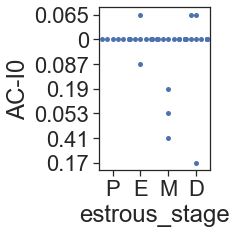

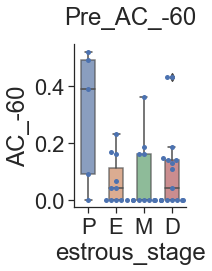

In [153]:
# IH current
ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
       'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)', 'AC-I0', 'AC_-60']

for state in ['Pre']:
    for column in ls:
        state_df = ephys[ephys.Behaviour_6hFD == state]
        state_df['estrous_stage'] = pd.Categorical(state_df['estrous_stage'], ['P', 'E', 'M', 'D'])
        
        try:

            print(stats.f_oneway(state_df[column][state_df['estrous_stage'] == 'P'].dropna(),
                                    state_df[column][state_df['estrous_stage'] == 'E'].dropna(),
                                    state_df[column][state_df['estrous_stage'] == 'M'].dropna(),
                                    state_df[column][state_df['estrous_stage'] == 'D'].dropna()))
            


            fig,ax = plt.subplots(figsize = (2,3))
            sns.swarmplot(x='estrous_stage', y =column, data= state_df, alpha = 1)
            sns.boxplot(x='estrous_stage', y =column, data= state_df, boxprops=dict(alpha=0.7), width = 0.5)
            sns.despine()
            plt.title(f'{state}_{column}', pad = 20)
            
            plt.show()
        except Exception:
            continue

cat_categ       no  yes  All
estrous_stage               
?                2    6    8
D               42   39   81
E               29   14   43
M               19   10   29
P               15   12   27
not taken        4    4    8
All            111   85  196
0.2099431992982078
cat_categ estrous_stage         no        yes
4                     P  55.555556  44.444444
2                     E  67.441860  32.558140
3                     M  65.517241  34.482759
1                     D  51.851852  48.148148


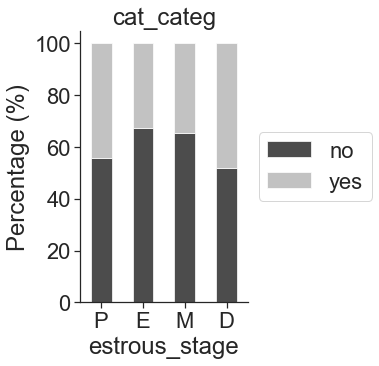

-0.0641323091459038 0.9358676908540962


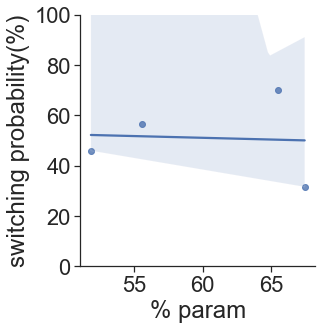

IH             no  yes  All
estrous_stage              
?               0    8    8
D              21   60   81
E              10   33   43
M              14   15   29
P               5   22   27
not taken       4    4    8
All            54  142  196
0.024230628517218786
IH estrous_stage         no        yes
4              P  18.518519  81.481481
2              E  23.255814  76.744186
3              M  48.275862  51.724138
1              D  25.925926  74.074074


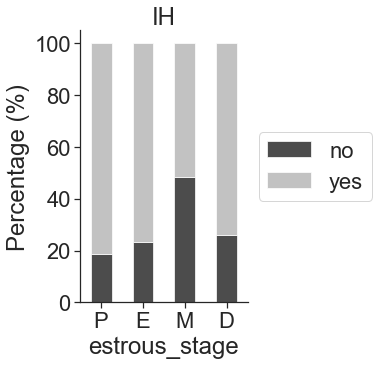

0.6720686747746435 0.3279313252253565


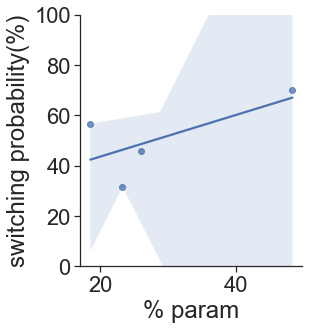

Adaptive       ?  no  yes  All
estrous_stage                 
?              0   0    2    2
D              0  19   23   42
E              0   7   24   31
M              0  13   13   26
P              2   4   11   17
All            2  43   73  118
0.010856272015613667
Adaptive estrous_stage         no        yes
4                    P  23.529412  64.705882
2                    E  22.580645  77.419355
3                    M  50.000000  50.000000
1                    D  45.238095  54.761905


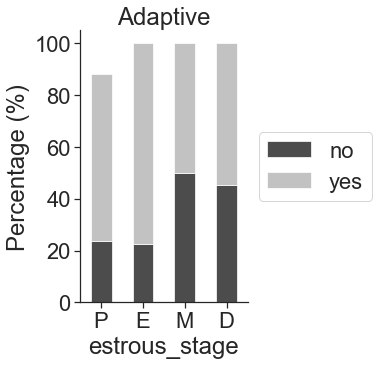

0.5850954623371792 0.41490453766282076


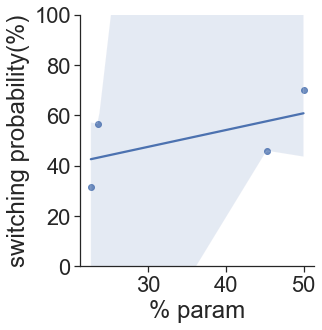

In [154]:
import scipy as sp
cols = ['no', 'yes']
ephys.loc[(ephys['Ih_at_-120mV'] == 0), 'IH']  = 'no'
ephys.loc[(ephys['Ih_at_-120mV'] >0 ), 'IH']  = 'yes'


estrous_df = pd.read_csv('../NPS_behaviour_analysis/generated_datasets/estrous_data.csv')
estrous_df.rename(columns = {'Unnamed: 0':'estrous_stage', '0':'switching probability'}, inplace = True)
ephys_pre = ephys[ephys.Behaviour_6hFD == 'Pre']

for column in ['cat_categ', 'IH', 'Adaptive']:
    esprop = proportion(ephys_pre, 'estrous_stage', column, cols)
    esprop['estrous_stage'] = pd.Categorical(esprop['estrous_stage'], ['P', 'E', 'M', 'D'])
    esprop = esprop.sort_values(by = ['estrous_stage']).dropna()
    prop_plot(esprop, 'estrous_stage')
    print(esprop)
    plt.title(column)
    plt.show()

    corr = pd.merge(esprop, estrous_df, on = 'estrous_stage')
    r, p = sp.stats.pearsonr(corr['switching probability'], corr['no'])
    print(r, p)

    sns.lmplot(x = 'no', y = 'switching probability', data = corr)
    plt.ylim([0, 100])
    plt.xlabel('% param')
    plt.ylabel('switching probability(%)')
    plt.show()

# npy administration

In [155]:
def pairline_plot(y, data):
    plt.subplots(figsize = (1.5,2))
    sns.lineplot(x = 'condition', y = y, hue = 'cell_id',data = data, palette = ['Tab:red'], alpha = 0.8)
    sns.swarmplot(x = 'condition', y = y ,data = data, palette = ['Tab:red'], alpha = 0.8)
    sns.boxplot(x = 'condition', y = y,data = data, palette = ['Tab:red'],boxprops=dict(alpha=.5), width = 0.5)
    ax = plt.gca()
    ax.get_legend().remove()
    sns.despine()
    plt.xticks(rotation = 90)
    plt.xlabel('')
    plt.show()

def sub_datset(data):

    vm = data.melt(id_vars=['cell_id'], value_vars=['Vm_control', 'Vm_drug'], var_name='condition', value_name='Vm')
    ir = data.melt(id_vars=['cell_id'], value_vars=['IR_control', 'IR_drug'], var_name='condition', value_name='IR')
    ih = data.melt(id_vars=['cell_id'], value_vars=['Ih_control', 'Ih_drug'], var_name='condition', value_name='Ih')
    fr = data.melt(id_vars=['cell_id'], value_vars=['firing_freq_control', 'firing_freq_drug'], var_name='condition', value_name='firing_freq')

    return [vm, ir, ih, fr]
    

100npy


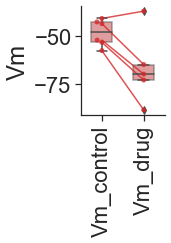

100npy


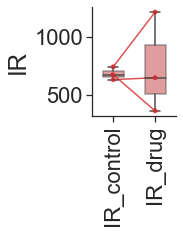

100npy


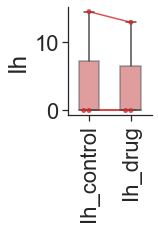

100npy


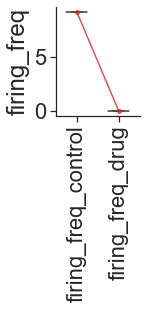

10npy


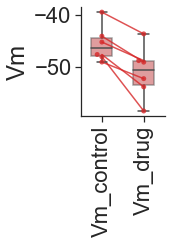

10npy


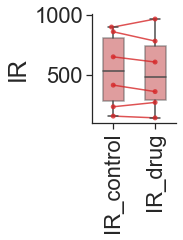

10npy


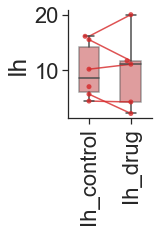

10npy


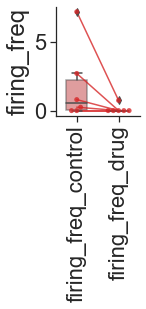

In [156]:
df = pd.read_csv('pharmacology.csv')
df['drug'] = df.conc_nM.astype(str) + df.identity


for drug in df.drug.unique()[:-1]:
    drug_df = df[df.drug == drug]
    df_list = sub_datset(drug_df)

    for subdata in df_list:
        
        subdata  = subdata.dropna()
        if len(subdata.condition.unique()) <2:
            continue
        else:
            print(drug)
            pairline_plot(str(subdata.columns[2]), subdata)